# 1. General

In [1]:
import os, pandas as pd
from unfairness.utils.config_loader import load_hparams
from unfairness.utils.misc import mask_ids
from unfairness.trainer import train_one_from_splits
from unfairness.reports.plots import plot_losses, plot_f1 
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [6]:
CSV_PATH = "local_database/ToS_100/ToS_100.csv"
KB_DIR   = "local_database/KB"
DIST_CFG = "configs/distributed_model_config.json"
FOLD_DIR = "cv_test/torch/fold_1"         
MAX_LEN  = 128
BATCH    = 32                        
SEED     = 42
TRAIN_FRAC = 0.70   
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15 

In [7]:
os.makedirs(FOLD_DIR, exist_ok=True)
hparams = load_hparams(DIST_CFG)
df = pd.read_csv(CSV_PATH)

if "label" in df.columns:
    y = df["label"].astype(int).values

X_Tv, X_t, y_Tv, y_t = train_test_split(
    df, y, test_size = TEST_FRAC, random_state = SEED, shuffle = True, stratify = y
)

X_T, X_v, y_T, y_v = train_test_split(
    X_Tv, y_Tv, test_size = VAL_FRAC / (VAL_FRAC + TRAIN_FRAC), random_state = SEED, shuffle = True, stratify = y_Tv
)

tr_csv = os.path.join(FOLD_DIR, "train.csv")
va_csv = os.path.join(FOLD_DIR, "val.csv")
te_csv = os.path.join(FOLD_DIR, "test.csv")

os.makedirs(FOLD_DIR, exist_ok=True)
X_T.to_csv(tr_csv, index=False)
X_v.to_csv(va_csv, index=False)
X_t.to_csv(te_csv, index=False)

X_T.shape, X_v.shape, X_t.shape

((14291, 19), (3063, 19), (3063, 19))

# 2. Entrenamiento

In [8]:
best_ckpt, metrics = train_one_from_splits(
    train_csv=tr_csv,
    val_csv=va_csv,
    test_csv=te_csv,
    hparams=hparams,
    out_dir=FOLD_DIR,
    kb_dir=KB_DIR,
    max_len=MAX_LEN,
    batch_size=BATCH
)
print("best_ckpt:", best_ckpt)
print("metrics :", metrics)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3060') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/nvme/git/contest/hackathon2025/.venv/lib/python3.13/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /nvme/git/contest/hackathon2025/cv_test/torch/fold_1 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type              | Params | Mode 
---------------------------------------------------------
0 | model      | Memory            | 1.1 M  | train
1 | f1_multi   | MultilabelF1Score | 0      | train
2 | f1_general | BinaryF1Score     | 0      

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/nvme/git/contest/hackathon2025/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/nvme/git/contest/hackathon2025/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 32. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


/nvme/git/contest/hackathon2025/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 447/447 [00:06<00:00, 69.64it/s, v_num=1]

...

Epoch 1:   2%|▏         | 11/447 [00:00<00:05, 74.19it/s, v_num=1, val_f1_score=0.000, val_loss=0.0554, train_loss=0.0781] 

/nvme/git/contest/hackathon2025/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 23. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


Epoch 31: 100%|██████████| 447/447 [00:07<00:00, 59.90it/s, v_num=1, val_f1_score=0.226, val_loss=0.108, train_loss=0.00139] 


Restoring states from the checkpoint path at /nvme/git/contest/hackathon2025/cv_test/torch/fold_1/best-v7.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /nvme/git/contest/hackathon2025/cv_test/torch/fold_1/best-v7.ckpt
/nvme/git/contest/hackathon2025/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 96/96 [00:00<00:00, 119.91it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_f1_general        0.5116358399391174
      test_f1_score         0.24936768412590027
        test_loss           0.06363694369792938
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
best_ckpt: /nvme/git/contest/hackathon2025/cv_test/torch/fold_1/best-v7.ckpt
metrics : {'val_f1': 0.22561879456043243, 'test_f1': 0.0, 'test_accuracy': 0.0}


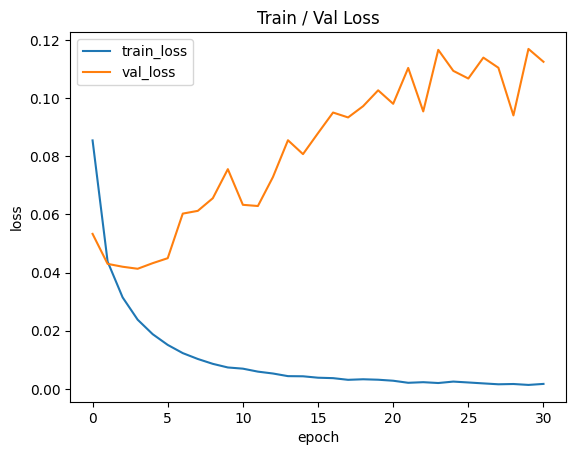

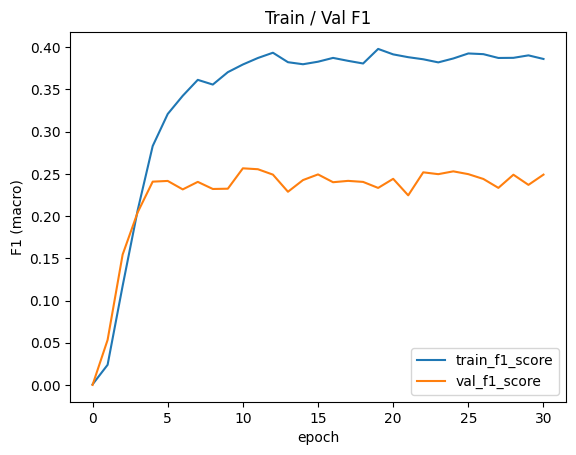

In [9]:
plot_losses("cv_test/torch/fold_1/logs/version_0/metrics.csv", smooth=1, show=True, save_path=os.path.join("cv_test/torch/fold_1/logs/version_0", "loss.png"))
plot_f1("cv_test/torch/fold_1/logs/version_0/metrics.csv",     smooth=1, show=True, save_path=os.path.join("cv_test/torch/fold_1/logs/version_0", "f1.png"))

# 3. Gráficos

In [12]:
import torch
from sklearn.metrics import classification_report
from unfairness.utils.config_loader import load_model_and_tokenizer
from unfairness.dataset import ToS, make_dataloaders

lit, tok, kb_struct = load_model_and_tokenizer(
    ckpt_path=best_ckpt,
    max_len=MAX_LEN,
    kb_dir=KB_DIR,
    map_location="cuda",  
)
lit.eval()
ds_test = ToS(pd.read_csv(te_csv), tok, MAX_LEN)
_, _, te_loader = make_dataloaders(ds_test, None, ds_test, batch_size=BATCH)

all_probs, all_preds, all_gold = [], [], []
device = next(lit.parameters()).device

with torch.no_grad():
    for batch in te_loader:
        x = batch["input_ids"].to(device, non_blocking=True)
        logits, *_ = lit(x)
        probs = logits.sigmoid().cpu()
        preds = (probs > 0.5).to(torch.int)
        all_probs.append(probs)
        all_preds.append(preds)
        all_gold.append(batch["labels_multi"].cpu())

import numpy as np
P = torch.cat(all_preds).numpy()
G = torch.cat(all_gold).numpy()

print("=== Multi-label (A,CH,CR,LTD,TER) ===")
print(classification_report(G, P, target_names=["A","CH","CR","LTD","TER"], zero_division=0))

Pg = (P.max(axis=1) > 0).astype(int)
Gg = (G.max(axis=1) > 0).astype(int)
print("=== General (OR derivado) ===")
print(classification_report(Gg, Pg, target_names=["fair","unfair"], zero_division=0))

=== Multi-label (A,CH,CR,LTD,TER) ===
              precision    recall  f1-score   support

           A       0.38      0.38      0.38        16
          CH       0.59      0.67      0.63        52
          CR       0.62      0.51      0.56        35
         LTD       0.61      0.67      0.64        85
         TER       0.55      0.69      0.61        64

   micro avg       0.58      0.63      0.60       252
   macro avg       0.55      0.58      0.56       252
weighted avg       0.58      0.63      0.60       252
 samples avg       0.05      0.05      0.05       252

=== General (OR derivado) ===
              precision    recall  f1-score   support

        fair       0.97      0.97      0.97      2833
      unfair       0.64      0.69      0.66       230

    accuracy                           0.95      3063
   macro avg       0.81      0.83      0.82      3063
weighted avg       0.95      0.95      0.95      3063



In [ ]:
import torch
from sklearn.metrics import classification_report
from unfairness.utils.config_loader import load_model_and_tokenizer
from unfairness.dataset import ToS, make_dataloaders

lit, tok, kb_struct = load_model_and_tokenizer(
    ckpt_path=best_ckpt,
    max_len=MAX_LEN,
    kb_dir=KB_DIR,
    map_location="cuda",  
)
lit.eval()
ds_test = ToS(pd.read_csv(te_csv), tok, MAX_LEN)
_, _, te_loader = make_dataloaders(ds_test, None, ds_test, batch_size=BATCH)

all_probs, all_preds, all_gold = [], [], []
device = next(lit.parameters()).device

with torch.no_grad():
    for batch in te_loader:
        x = batch["input_ids"].to(device, non_blocking=True)
        logits, *_ = lit(x)
        probs = logits.sigmoid().cpu()
        preds = (probs > 0.5).to(torch.int)
        all_probs.append(probs)
        all_preds.append(preds)
        all_gold.append(batch["labels_multi"].cpu())

import numpy as np
P = torch.cat(all_preds).numpy()
G = torch.cat(all_gold).numpy()

print("=== Multi-label (A,CH,CR,LTD,TER) ===")
print(classification_report(G, P, target_names=["A","CH","CR","LTD","TER"], zero_division=0))

Pg = (P.max(axis=1) > 0).astype(int)
Gg = (G.max(axis=1) > 0).astype(int)
print("=== General (OR derivado) ===")
print(classification_report(Gg, Pg, target_names=["fair","unfair"], zero_division=0))

=== Multi-label (A,CH,CR,LTD,TER) ===
              precision    recall  f1-score   support

           A       0.38      0.38      0.38        16
          CH       0.59      0.67      0.63        52
          CR       0.62      0.51      0.56        35
         LTD       0.61      0.67      0.64        85
         TER       0.55      0.69      0.61        64

   micro avg       0.58      0.63      0.60       252
   macro avg       0.55      0.58      0.56       252
weighted avg       0.58      0.63      0.60       252
 samples avg       0.05      0.05      0.05       252

=== General (OR derivado) ===
              precision    recall  f1-score   support

        fair       0.97      0.97      0.97      2833
      unfair       0.64      0.69      0.66       230

    accuracy                           0.95      3063
   macro avg       0.81      0.83      0.82      3063
weighted avg       0.95      0.95      0.95      3063

